In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET
import os
import cv2
import matplotlib.pyplot as plt
import random
import shutil
import yaml

In [3]:
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

In [13]:
from IPython.display import Image

**from ultralytics docs**

The dataset label format used for training YOLO pose models is as follows:

One text file per image: Each image in the dataset has a corresponding text file with the same name as the image file and the ".txt" extension.

One row per object: Each row in the text file corresponds to one object instance in the image.

Object information per row: Each row contains the following information about the object instance:


1. Object class index: An integer representing the class of the object (e.g., 0 for person, 1 for car, etc.).

2. Object center coordinates: The x and y coordinates of the center of the object, normalized to be between 0 and 1.

3. Object width and height: The width and height of the object, normalized to be between 0 and 1.

4. Object keypoint coordinates: The keypoints of the object, normalized to be between 0 and 1.

In [3]:
classes = ['helmet','head','person']

In [4]:
def convert_bbox_to_yolo(image_width, image_height, bbox):
    xmin, ymin, xmax, ymax = bbox
    xmin = max(0, min(xmin, image_width))
    xmax = max(0, min(xmax, image_width))
    ymin = max(0, min(ymin, image_height))
    ymax = max(0, min(ymax, image_height))
    box_width  = xmax - xmin
    box_height = ymax - ymin
    x_center   = (xmin + box_width  / 2) / image_width
    y_center   = (ymin + box_height / 2) / image_height
    box_width  /= image_width
    box_height /= image_height
    return x_center, y_center, box_width, box_height

In [34]:
src_labels_path = r"src_labels"
xml_path = r"annotations"
src_imgs_path = r"src_imgs"

In [ ]:
print(os.listdir(xml_path))

['hard_hat_workers0.xml', 'hard_hat_workers1.xml', 'hard_hat_workers10.xml', 'hard_hat_workers100.xml', 'hard_hat_workers1000.xml', 'hard_hat_workers1001.xml', 'hard_hat_workers1002.xml', 'hard_hat_workers1003.xml', 'hard_hat_workers1004.xml', 'hard_hat_workers1005.xml', 'hard_hat_workers1006.xml', 'hard_hat_workers1007.xml', 'hard_hat_workers1008.xml', 'hard_hat_workers1009.xml', 'hard_hat_workers101.xml', 'hard_hat_workers1010.xml', 'hard_hat_workers1011.xml', 'hard_hat_workers1012.xml', 'hard_hat_workers1013.xml', 'hard_hat_workers1014.xml', 'hard_hat_workers1015.xml', 'hard_hat_workers1016.xml', 'hard_hat_workers1017.xml', 'hard_hat_workers1018.xml', 'hard_hat_workers1019.xml', 'hard_hat_workers102.xml', 'hard_hat_workers1020.xml', 'hard_hat_workers1021.xml', 'hard_hat_workers1022.xml', 'hard_hat_workers1023.xml', 'hard_hat_workers1024.xml', 'hard_hat_workers1025.xml', 'hard_hat_workers1026.xml', 'hard_hat_workers1027.xml', 'hard_hat_workers1028.xml', 'hard_hat_workers1029.xml', 'h

**convert xml to Yolo format**

In [ ]:
for xml in os.listdir(xml_path):
    if not xml.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_path, xml))
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)
    txt_name = xml.replace(".xml", ".txt")
    with open(os.path.join(src_labels_path, txt_name), "w") as f:
        for obj in root.findall("object"):
            cls = obj.find("name").text
            cls_id = classes.index(cls)

            bnd_box = obj.find("bndbox")
            bbox = []
            bbox.append(float(bnd_box.find("xmin").text))
            bbox.append(float(bnd_box.find("ymin").text))
            bbox.append(float(bnd_box.find("xmax").text))
            bbox.append(float(bnd_box.find("ymax").text))

            x_center, y_center, box_width, box_height = convert_bbox_to_yolo(width, height, bbox)

            f.write(
                f"{cls_id} {x_center:.6f} {y_center:.6f} "
                f"{box_width:.6f} {box_height:.6f}\n"
            )

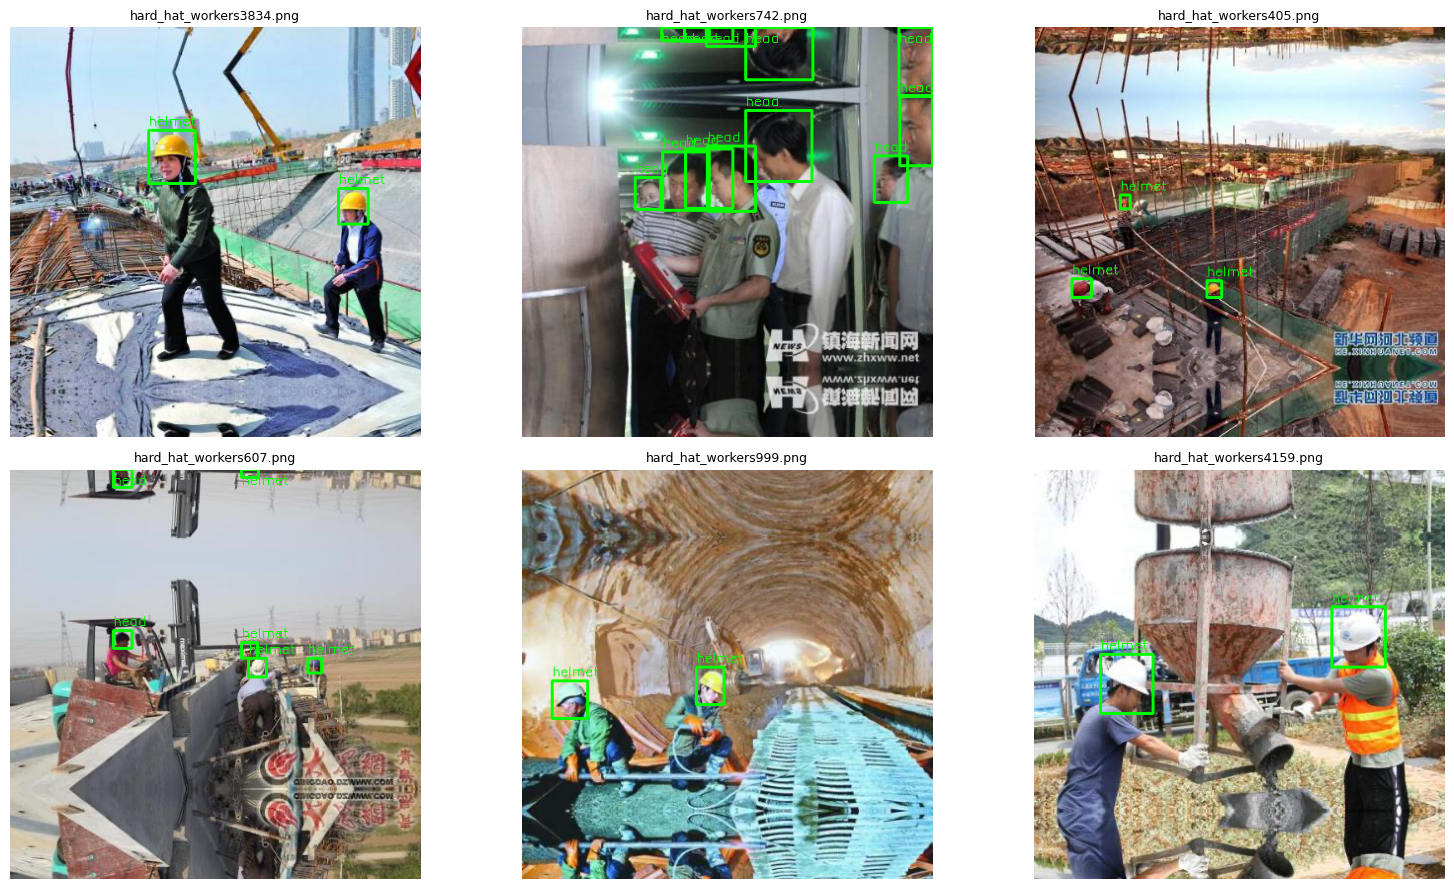

In [ ]:
def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    if os.path.exists(label_path):
        for line in open(label_path).readlines():
            vals = line.strip().split()
            if len(vals) != 5:
                continue
            cls_id = int(vals[0])
            xc, yc, bw, bh = map(float, vals[1:])
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, class_names[cls_id], (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1)
    return image

sample_train = random.sample(os.listdir(src_imgs_path), 6)
plt.figure(figsize=(16, 9))

for i, image_file in enumerate(sample_train):
    image_name = os.path.splitext(image_file)[0]
    img_path   = os.path.join(src_imgs_path, image_file)
    lbl_path   = os.path.join(src_labels_path, image_name + ".txt")
    img = draw_yolo_boxes(img_path, lbl_path, classes)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_file, fontsize=9)

plt.tight_layout()
plt.show()

**split data**

In [29]:
image_list = os.listdir(src_imgs_path)
train_data, temp_data = train_test_split(image_list, test_size=0.2, random_state=42, shuffle=True)
test_data, Val_data = train_test_split(temp_data, test_size=0.5, random_state=42, shuffle=True)

print(f"Train size: {len(train_data)}\nTest size: {len(test_data)}\nVal size: {len(Val_data)}")

Train size: 4000
Test size: 500
Val size: 500


In [35]:
def copy_files(file_list, split, src_img, src_lbl, dst_root="data"):

    img_dst = os.path.join(dst_root, "images", split)
    lbl_dst = os.path.join(dst_root, "labels", split)

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    for img_name in file_list:

        shutil.copy2(
            os.path.join(src_img, img_name),
            os.path.join(img_dst, img_name)
        )

        label_name = os.path.splitext(img_name)[0] + ".txt"

        shutil.copy2(
            os.path.join(src_lbl, label_name),
            os.path.join(lbl_dst, label_name)
        )

In [36]:
copy_files(train_data, "train", src_imgs_path, src_labels_path)
copy_files(test_data,   "val",   src_imgs_path, src_labels_path)
copy_files(Val_data,  "test",  src_imgs_path, src_labels_path)

In [38]:
data = {
        "path": "data",
        "train" : "images/train",
        "val"   : "images/val",
        "test"  : "images/test",
        "nc"    : len(classes),
        "names" : classes
    }

data_path = r"data.yaml"

with open(data_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

**Model**

In [40]:
# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

In [ ]:
# Train the model
results = model.train(data="data.yaml", epochs=100, imgsz=640) # from ultralytics docs

Ultralytics 8.4.95  Python-3.12.5 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

In [ ]:
df = pd.read_csv(r"runs\detect\train\results.csv")

In [16]:
df.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

[]

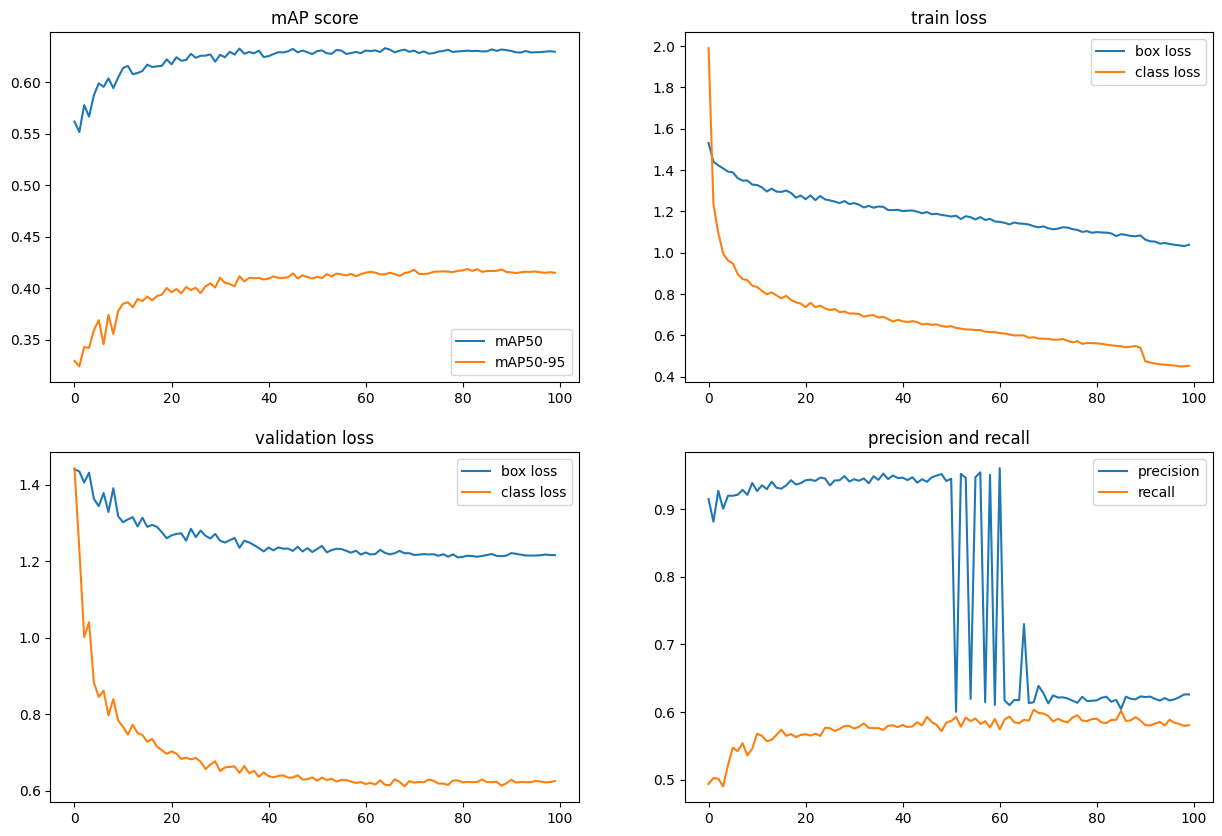

In [43]:
fig, axes = plt.subplots(2,2, figsize=(15, 10))

axes[0,0].plot(df['metrics/mAP50(B)'], label="mAP50")
axes[0,0].plot(df['metrics/mAP50-95(B)'], label="mAP50-95")
axes[0,0].set_title("mAP score")
axes[0,0].legend()

axes[0,1].plot(df["train/box_loss"], label="box loss")
axes[0,1].plot(df["train/cls_loss"], label="class loss")
axes[0,1].set_title("train loss")
axes[0,1].legend()

axes[1,0].plot(df["val/box_loss"], label="box loss")
axes[1,0].plot(df["val/cls_loss"], label="class loss")
axes[1,0].set_title("validation loss")
axes[1,0].legend()

axes[1,1].plot(df["metrics/precision(B)"], label="precision")
axes[1,1].plot(df["metrics/recall(B)"], label="recall")
axes[1,1].set_title("precision and recall")
axes[1,1].legend()

plt.plot()